In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
data_dir = "/kaggle/input/datasets/afridirahman/brain-stroke-ct-image-dataset/Brain_Data_Organised"

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


In [6]:
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Classes:", dataset.classes)

labels = np.array([dataset.samples[i][1] for i in range(len(dataset))])
print("Class distribution:", np.bincount(labels))


Classes: ['Normal', 'Stroke']
Class distribution: [1551  950]


In [7]:
train_idx, temp_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=labels[temp_idx],
    random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 1750
Val: 375
Test: 376


In [8]:
class DenseNet121_Model(nn.Module):
    def __init__(self):
        super(DenseNet121_Model, self).__init__()
        
        self.backbone = models.densenet121(weights="IMAGENET1K_V1")
        
        num_features = self.backbone.classifier.in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        return self.backbone(x)


model = DenseNet121_Model().to(device)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 210MB/s]


In [9]:
num_normal = np.sum(labels == 0)
num_stroke = np.sum(labels == 1)

pos_weight = torch.tensor([num_normal / num_stroke]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=5e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)


In [10]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

epochs = 30

for epoch in range(epochs):

    # TRAIN
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for images, labels_batch in train_loader:
        
        images = images.to(device)
        labels_batch = labels_batch.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)
        outputs = torch.clamp(outputs, -50, 50)

        loss = criterion(outputs, labels_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        train_preds.extend(preds.cpu().numpy().ravel())
        train_labels.extend(labels_batch.cpu().numpy().ravel())

    train_acc = accuracy_score(train_labels, train_preds)

    # VALIDATION
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, labels_batch in val_loader:

            images = images.to(device)
            labels_batch = labels_batch.float().unsqueeze(1).to(device)

            outputs = model(images)
            outputs = torch.clamp(outputs, -50, 50)

            loss = criterion(outputs, labels_batch)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            val_preds.extend(preds.cpu().numpy().ravel())
            val_labels.extend(labels_batch.cpu().numpy().ravel())

    val_acc = accuracy_score(val_labels, val_preds)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss/len(train_loader))
    history["val_loss"].append(val_loss/len(val_loader))
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")


Epoch 1/30 | Train Loss: 0.8244 | Val Loss: 0.7332
Epoch 2/30 | Train Loss: 0.6482 | Val Loss: 0.5894
Epoch 3/30 | Train Loss: 0.4965 | Val Loss: 0.4253
Epoch 4/30 | Train Loss: 0.3842 | Val Loss: 0.3826
Epoch 5/30 | Train Loss: 0.2701 | Val Loss: 0.2915
Epoch 6/30 | Train Loss: 0.1914 | Val Loss: 0.2759
Epoch 7/30 | Train Loss: 0.1659 | Val Loss: 0.1928
Epoch 8/30 | Train Loss: 0.1229 | Val Loss: 0.2398
Epoch 9/30 | Train Loss: 0.1054 | Val Loss: 0.2249
Epoch 10/30 | Train Loss: 0.0921 | Val Loss: 0.1919
Epoch 11/30 | Train Loss: 0.0758 | Val Loss: 0.1645
Epoch 12/30 | Train Loss: 0.0880 | Val Loss: 0.2054
Epoch 13/30 | Train Loss: 0.0526 | Val Loss: 0.1904
Epoch 14/30 | Train Loss: 0.0506 | Val Loss: 0.1102
Epoch 15/30 | Train Loss: 0.0666 | Val Loss: 0.1696
Epoch 16/30 | Train Loss: 0.0438 | Val Loss: 0.1912
Epoch 17/30 | Train Loss: 0.0323 | Val Loss: 0.1674
Epoch 18/30 | Train Loss: 0.0414 | Val Loss: 0.2340
Epoch 19/30 | Train Loss: 0.0153 | Val Loss: 0.1371
Epoch 20/30 | Train L

In [11]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels_batch in test_loader:

        images = images.to(device)
        outputs = model(images)
        outputs = torch.clamp(outputs, -50, 50)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().ravel())
        all_labels.extend(labels_batch.numpy())
        all_probs.extend(probs.cpu().numpy().ravel())

print("\nCLASSIFICATION REPORT:\n")
print(classification_report(all_labels, all_preds, target_names=["Normal","Stroke"]))

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds))
print("AUC:", roc_auc_score(all_labels, all_probs))



CLASSIFICATION REPORT:

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99       233
      Stroke       0.97      0.99      0.98       143

    accuracy                           0.98       376
   macro avg       0.98      0.98      0.98       376
weighted avg       0.98      0.98      0.98       376

Accuracy: 0.9840425531914894
Precision: 0.9724137931034482
Recall: 0.986013986013986
F1 Score: 0.9791666666666666
AUC: 0.9979291095170923


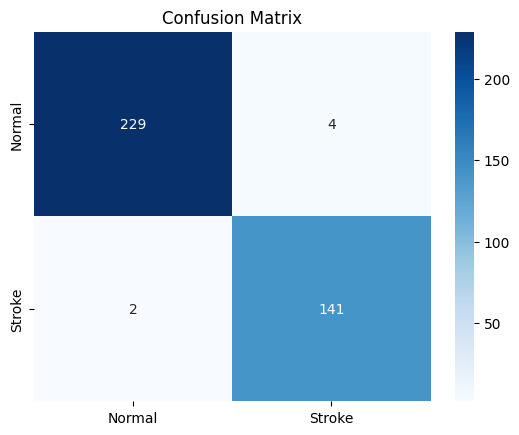

In [12]:
cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal","Stroke"],
            yticklabels=["Normal","Stroke"],
            cmap="Blues")

plt.title("Confusion Matrix")
plt.show()


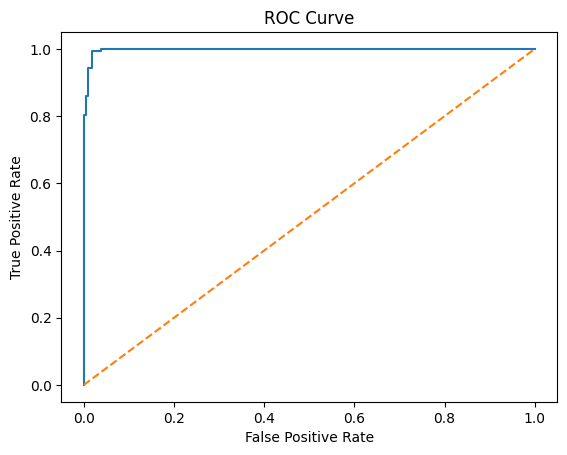

In [13]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


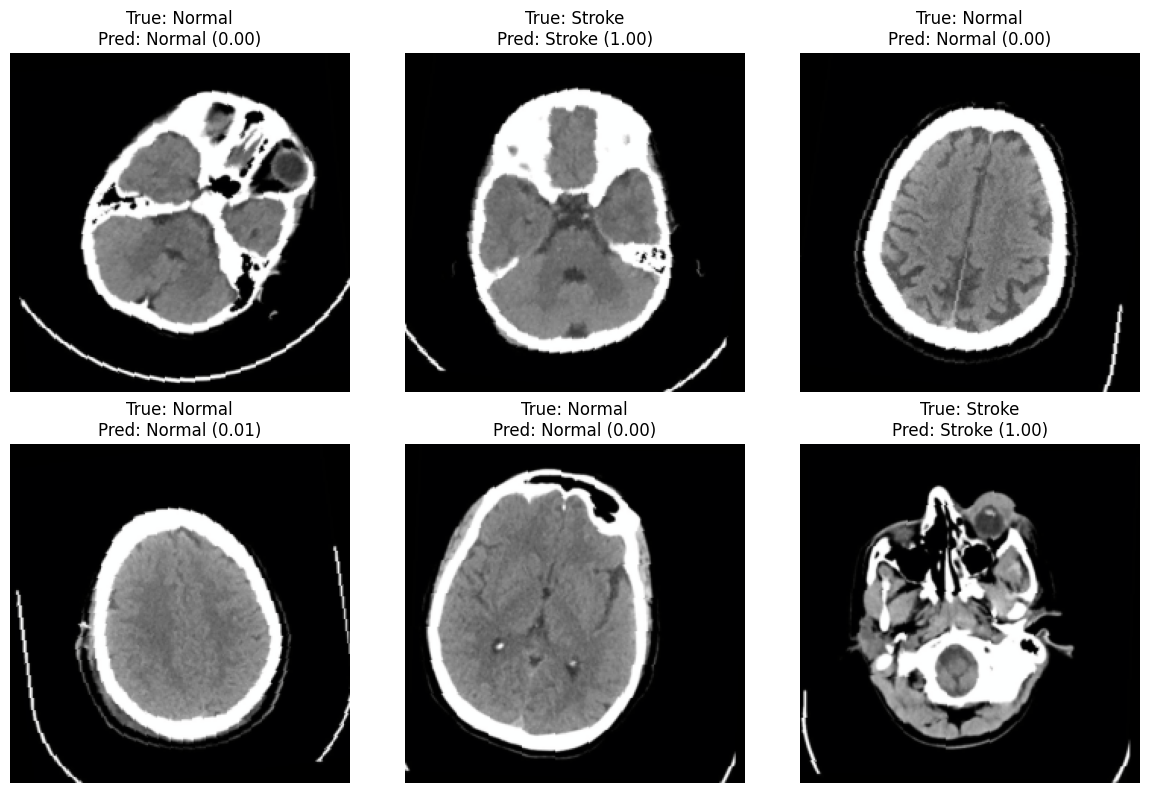

In [14]:
model.eval()

num_images = 6
count = 0

plt.figure(figsize=(12, 8))

with torch.no_grad():
    for images, labels_batch in test_loader:

        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        for i in range(images.size(0)):

            img = images[i].cpu().permute(1,2,0).numpy()
            img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
            img = np.clip(img, 0, 1)

            true_label = "Stroke" if labels_batch[i] == 1 else "Normal"
            pred_label = "Stroke" if preds[i] == 1 else "Normal"
            confidence = probs[i].item()

            plt.subplot(2, 3, count+1)
            plt.imshow(img)
            plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})")
            plt.axis("off")

            count += 1

            if count == num_images:
                break
        if count == num_images:
            break

plt.tight_layout()
plt.show()


In [26]:
class DenseNet121_Model(nn.Module):
    def __init__(self):
        super(DenseNet121_Model, self).__init__()

        backbone = models.densenet121(weights="IMAGENET1K_V1")

        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        num_features = backbone.classifier.in_features

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        features = self.features(x)

        # Clone to avoid inplace issue
        features = features.clone()

        out = torch.relu(features)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.classifier(out)

        return out


model = DenseNet121_Model().to(device)


In [27]:
import cv2

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        self.model.features.register_forward_hook(self.forward_hook)
        self.model.features.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image):
        self.model.eval()

        output = self.model(input_image)

        self.model.zero_grad()
        output.backward(torch.ones_like(output))

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1,2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i in range(len(weights)):
            cam += weights[i] * activations[i]

        cam = torch.relu(cam)
        cam = cam.detach().cpu().numpy()

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam


In [28]:
gradcam = GradCAM(model)


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4000000059604645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4000000059604645].


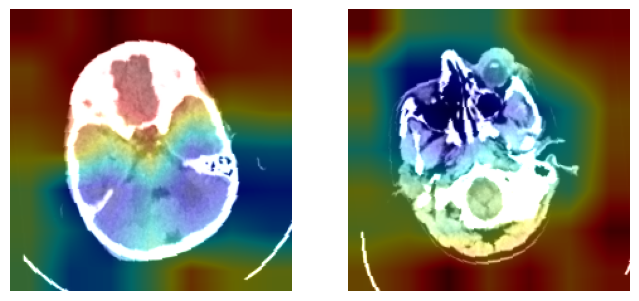

In [29]:
model.eval()

plt.figure(figsize=(8,6))
count = 0

for images, labels_batch in test_loader:

    for i in range(len(labels_batch)):

        if labels_batch[i].item() == 1:  # Stroke class

            input_image = images[i].unsqueeze(0).to(device)
            original_image = images[i]

            heatmap = gradcam.generate(input_image)

            img = original_image.cpu().permute(1,2,0).numpy()
            img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
            img = np.clip(img, 0, 1)

            heatmap = cv2.resize(heatmap, (224,224))
            heatmap = np.uint8(255 * heatmap)
            heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
            heatmap = heatmap.astype(np.float32) / 255

            overlay = heatmap * 0.4 + img

            plt.subplot(1,2,count+1)
            plt.imshow(overlay)
            plt.axis("off")

            count += 1

            if count == 2:
                break
    if count == 2:
        break

plt.show()


5 FLOD CROSS

In [31]:
from sklearn.model_selection import StratifiedKFold


In [32]:
class DenseNet121_Model(nn.Module):
    def __init__(self):
        super(DenseNet121_Model, self).__init__()

        backbone = models.densenet121(weights="IMAGENET1K_V1")

        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        num_features = backbone.classifier.in_features

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        features = self.features(x)
        features = features.clone() # avoid inplace issue
        out = torch.relu(features)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.classifier(out)
        return out


In [33]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [34]:
fold_results = {
    "accuracy": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for fold, (train_idx, val_idx) in enumerate(
        kfold.split(np.arange(len(dataset)), labels)):

    print(f"\n===== FOLD {fold+1} =====")

    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

    model = DenseNet121_Model().to(device)

    # Weighted loss per fold
    num_normal = np.sum(labels[train_idx] == 0)
    num_stroke = np.sum(labels[train_idx] == 1)

    pos_weight = torch.tensor([num_normal / num_stroke]).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=5e-5)

    epochs = 10   # increase to 20 if needed

    # ---- Training ----
    for epoch in range(epochs):

        model.train()

        for images, labels_batch in train_loader:

            images = images.to(device)
            labels_batch = labels_batch.float().unsqueeze(1).to(device)

            optimizer.zero_grad()

            outputs = model(images)
            outputs = torch.clamp(outputs, -50, 50)

            loss = criterion(outputs, labels_batch)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    # ---- Validation ----
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels_batch in val_loader:

            images = images.to(device)

            outputs = model(images)
            outputs = torch.clamp(outputs, -50, 50)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy().ravel())
            all_labels.extend(labels_batch.numpy())
            all_probs.extend(probs.cpu().numpy().ravel())

    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    fold_results["accuracy"].append(acc)
    fold_results["recall"].append(rec)
    fold_results["f1"].append(f1)
    fold_results["auc"].append(auc)

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"AUC: {auc:.4f}")



===== FOLD 1 =====
Accuracy: 0.9441
Recall: 0.9053
F1: 0.9247
AUC: 0.9848

===== FOLD 2 =====
Accuracy: 0.9360
Recall: 0.9474
F1: 0.9184
AUC: 0.9804

===== FOLD 3 =====
Accuracy: 0.9420
Recall: 0.9368
F1: 0.9247
AUC: 0.9865

===== FOLD 4 =====
Accuracy: 0.9360
Recall: 0.9474
F1: 0.9184
AUC: 0.9899

===== FOLD 5 =====
Accuracy: 0.9500
Recall: 0.9316
F1: 0.9340
AUC: 0.9890


In [35]:
print("\n===== FINAL 5-FOLD RESULTS =====")

for metric in fold_results:
    values = fold_results[metric]
    print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")



===== FINAL 5-FOLD RESULTS =====
ACCURACY: 0.9416 ± 0.0053
RECALL: 0.9337 ± 0.0155
F1: 0.9240 ± 0.0057
AUC: 0.9861 ± 0.0034
